In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from multitask_sparse_parity import MultitaskSparseParityDataset, MultitaskSparseParityModel
from storer import Storer
from train_mtsp_model_uniform_task_distribution_modal import TrainConfig
import seaborn as sns
import torch
import einops

/Users/jack/Desktop/Jack/tests/mats-9/scaling/spd-multitasksparseparity/spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# d_mlp = 16
storer = Storer("/modal_volume/mtsp_results/metrics/")
config = TrainConfig(seed=0)

storer.add_datestamp_prefix()
storer.add_prefix(f"train_mtsp_model_uniform_task_distribution/v10/{config.cache_key()}")

torch.manual_seed(config.seed)
model = MultitaskSparseParityModel(
    d_mlp=config.d_mlp, n_control_bits=config.n_control_bits, n_task_bits=config.n_task_bits
)
dataset = MultitaskSparseParityDataset(
    n_control_bits=config.n_control_bits,
    n_task_bits=config.n_task_bits,
    n_xored_bits=config.n_xored_bits,
    task_distribution_decay_rate=config.task_distribution_decay_rate,
    batch_sz=config.batch_sz,
    size=config.steps,
)
storer.add_prefix(f"model/{config.steps}")
key = "model"
assert storer.exists(key), storer
model.load_state_dict(storer.read(key))
losses_by_step_and_task: np.ndarray = storer.read("losses_by_step_and_task")

torch.manual_seed(0)
task_ids, task_bits, parity = dataset.get_batch(batch_sz=1024)
logits = model((task_ids, task_bits, ()))
val_loss = F.cross_entropy(logits, parity)
print(val_loss)

tensor(4.7147e-06, grad_fn=<NllLossBackward0>)


In [3]:
l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

In [17]:
# neuron_mask = torch.ones(model.l1.out_features).bool()
neuron_mask = ~(model.l1.weight.data.abs().amax(-1) < 1e-14)
assert (l2_synth[~neuron_mask] < 1e-14).all()
(~neuron_mask).sum(), (neuron_mask).sum()

(tensor(10), tensor(4))

In [18]:
l1_for_task0 = model.l1.weight.data[
    :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
]

In [19]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0[neuron_mask].T
x3 = F.relu(x2)
x4 = x3 @ l2_synth[neuron_mask]
x4

tensor([  9.8039, -10.5019, -10.5025,  14.3533])

In [20]:
bits.sum(-1) % 2

tensor([0, 1, 1, 0])

In [21]:
F.binary_cross_entropy_with_logits(x4, ((1 + bits.sum(-1)) % 2).float())

tensor(2.7783e-05)

<Axes: >

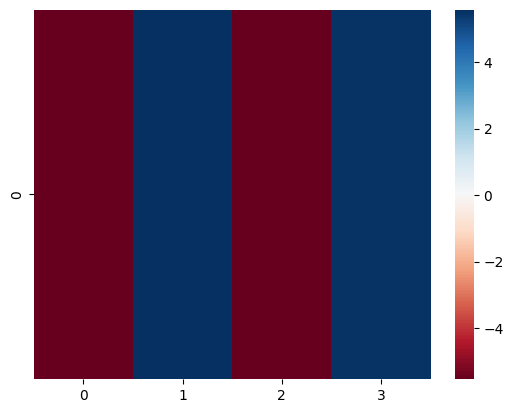

In [22]:
sns.heatmap((l2_synth[neuron_mask])[None], cmap='RdBu', center=0)

()

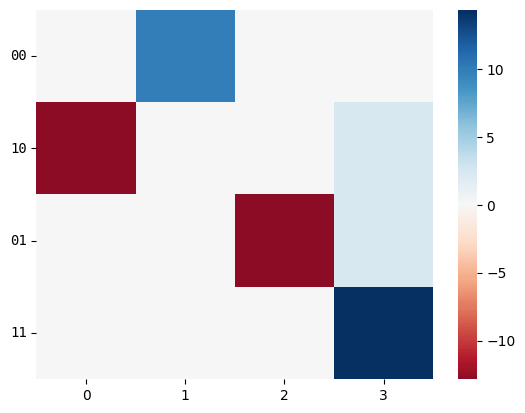

In [23]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

()

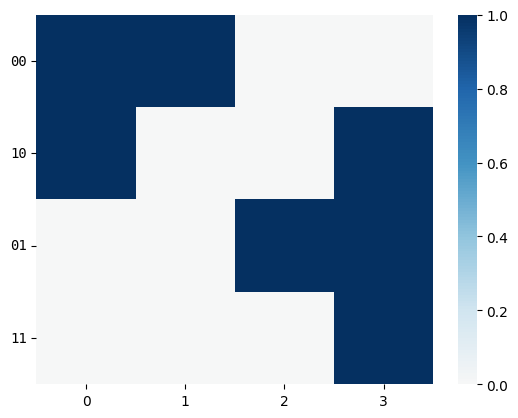

In [24]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x2 > 0, cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

<Axes: >

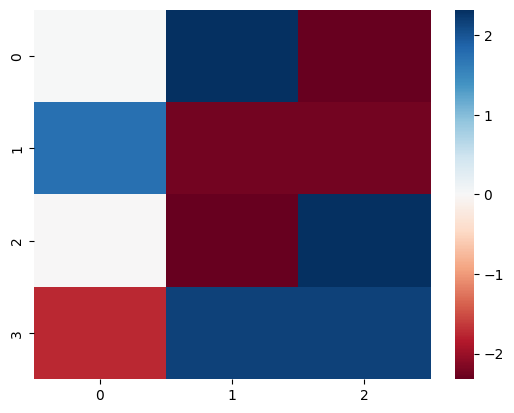

In [ ]:
sns.heatmap(data=l1_for_task0[neuron_mask], cmap='RdBu', center=0)

In [34]:
l2_synth[neuron_mask]

tensor([-5.5360,  5.5756, -5.5351,  5.5257])

In [32]:
l1_for_task0[neuron_mask]

tensor([[ 1.0261e-09,  2.3213e+00, -2.3213e+00],
        [ 1.7584e+00, -2.2425e+00, -2.2423e+00],
        [-4.8004e-07, -2.3217e+00,  2.3217e+00],
        [-1.7475e+00,  2.1726e+00,  2.1725e+00]])

()

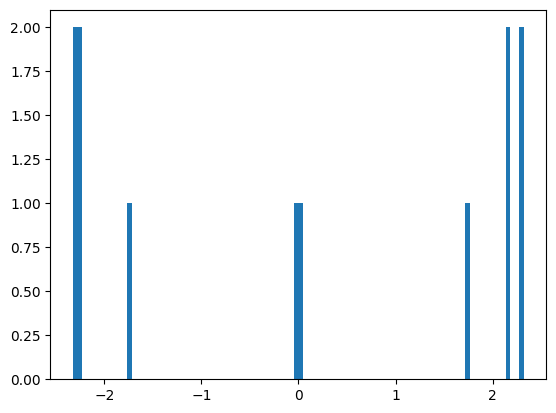

In [31]:
plt.hist(l1_for_task0[neuron_mask].reshape(-1), bins=100)
()

In [ ]:
sns.heatmap(data=l1_for_task0[neuron_mask], cmap='RdBu', center=0)


<Axes: >

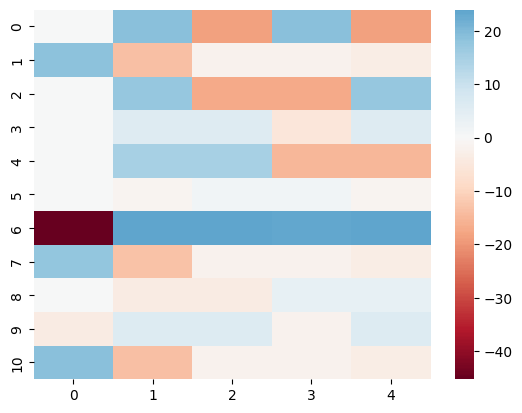

In [46]:
sns.heatmap((l1_for_task0[neuron_mask] * l2_synth[neuron_mask].unsqueeze(-1)), cmap='RdBu', center=0)

<Axes: >

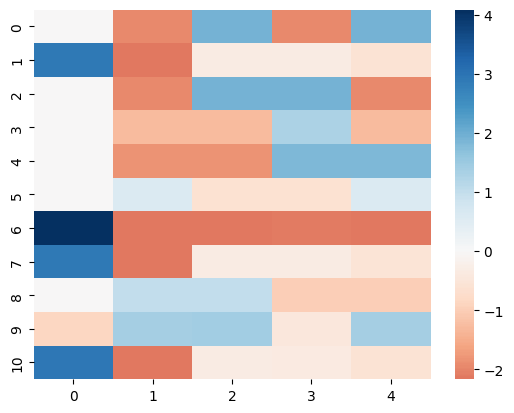

In [47]:
sns.heatmap((l1_for_task0[neuron_mask]), cmap='RdBu', center=0)

In [36]:
l1_for_task0[neuron_mask]

tensor([[-1.7880e-07, -1.9302e+00,  1.9302e+00, -1.9302e+00,  1.9302e+00],
        [ 2.9185e+00, -2.1487e+00, -3.2018e-01, -3.3309e-01, -5.6146e-01],
        [-4.3435e-07, -1.9284e+00,  1.9284e+00,  1.9284e+00, -1.9284e+00],
        [-5.9614e-08, -1.2804e+00, -1.2804e+00,  1.2804e+00, -1.2804e+00],
        [-5.4794e-07, -1.8301e+00, -1.8301e+00,  1.8301e+00,  1.8301e+00],
        [-3.0522e-08,  6.1450e-01, -6.1450e-01, -6.1450e-01,  6.1450e-01],
        [ 4.0840e+00, -2.1572e+00, -2.1607e+00, -2.1128e+00, -2.1602e+00],
        [ 2.8912e+00, -2.1276e+00, -3.1572e-01, -3.2806e-01, -5.5536e-01],
        [-3.0726e-08,  9.8395e-01,  9.8395e-01, -9.8395e-01, -9.8395e-01],
        [-8.6947e-01,  1.3813e+00,  1.4193e+00, -4.6507e-01,  1.3817e+00],
        [ 2.9440e+00, -2.1690e+00, -3.2436e-01, -3.3788e-01, -5.6711e-01]])

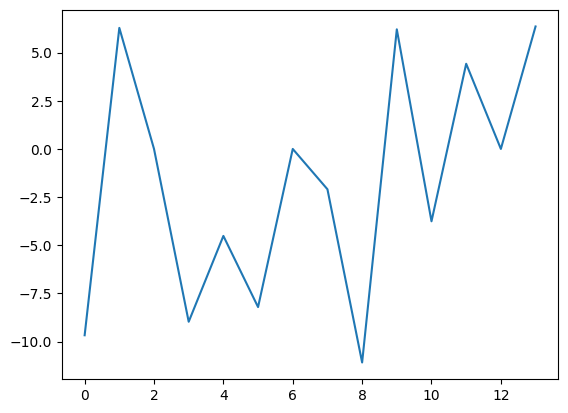

In [15]:
plt.plot(l2_synth)

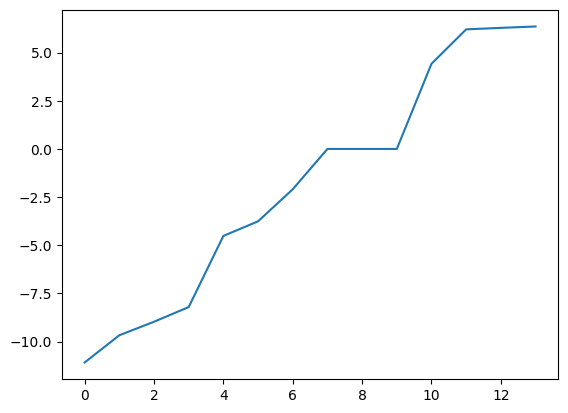

In [16]:
plt.plot(l2_synth[l2_synth.sort().indices])

In [17]:
dataset.selected_bits_by_task + 1

tensor([[24,  8, 10,  2]])

In [18]:
# sns.heatmap(model.l1.weight.data[l2_synth.sort().indices])

<Axes: >

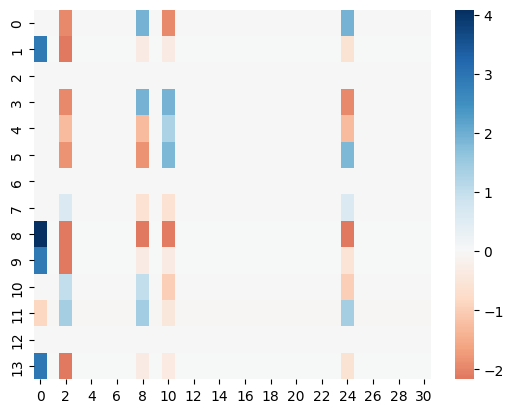

In [19]:
sns.heatmap(model.l1.weight.data, cmap="RdBu", center=0)

<Axes: >

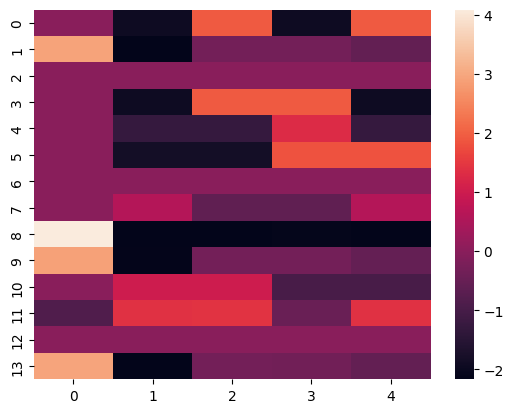

In [20]:
sns.heatmap(
    model.l1.weight.data[
        :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
    ]
)

In [21]:
l1_for_task0 = model.l1.weight.data[
    :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
]

In [22]:
F.relu(input=(torch.tensor([1, 0, 0, 0, 0]).float() @ l1_for_task0.T)) @ l2_synth

tensor(9.7345)

In [23]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0.T
x3 = F.relu(x2)
x4 = x3 @ l2_synth
x4

tensor([  9.7345,  -9.5743,  -9.5825,   9.6160, -11.2264,   8.4343,   8.4721,
        -12.3207,  -9.6165,   9.7221,   9.5887,  -9.0078,   8.3091,  -9.9947,
        -12.3969,  12.5898])

In [24]:
F.relu(l1_for_task0[:, 0]) @ l2_synth

tensor(9.7345)

<Axes: >

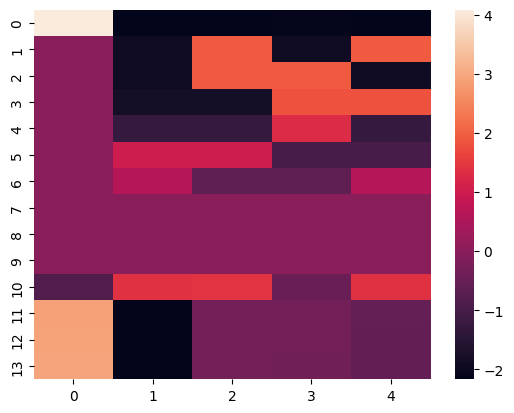

In [25]:
sns.heatmap(l1_for_task0[l2_synth.sort().indices])

In [26]:
# neuron_mask = torch.ones(model.l1.out_features).bool()
neuron_mask = ~(model.l1.weight.data.abs().amax(-1) < 1e-14)
assert (l2_synth[~neuron_mask] < 1e-14).all()
(~neuron_mask).sum()

tensor(3)

<Axes: >

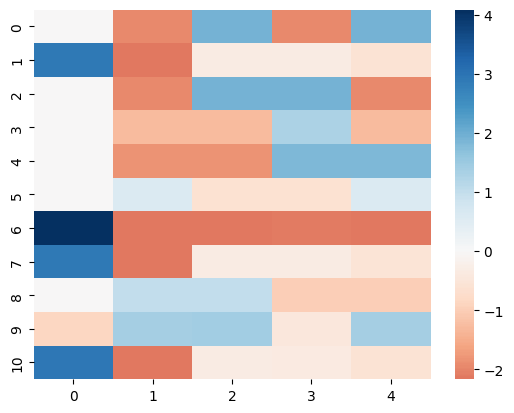

In [16]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

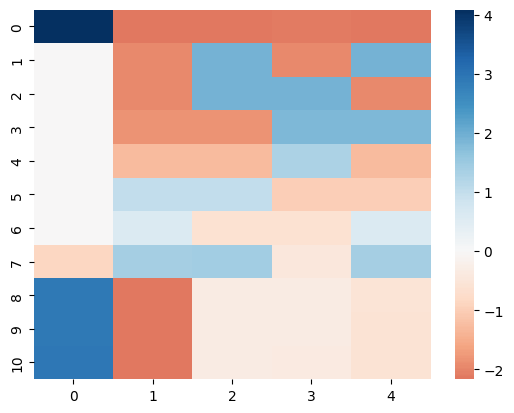

In [17]:
sns.heatmap(l1_for_task0[neuron_mask][l2_synth[neuron_mask].sort().indices], cmap="RdBu", center=0)

In [19]:
l2_synth[neuron_mask].sort().indices

tensor([4, 3, 2, 0, 6, 5, 1, 7])

In [20]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0[neuron_mask].T
x3 = F.relu(x2)
x4 = x3 @ l2_synth[neuron_mask]
x4

tensor([  8.3056, -10.2873, -10.2768,   9.6085, -10.2763,   9.6085,   9.4976,
         -9.4992, -10.2769,   9.6087,   9.4965,  -9.4995,   9.4973,  -9.4990,
        -12.2402,  14.1524])

()

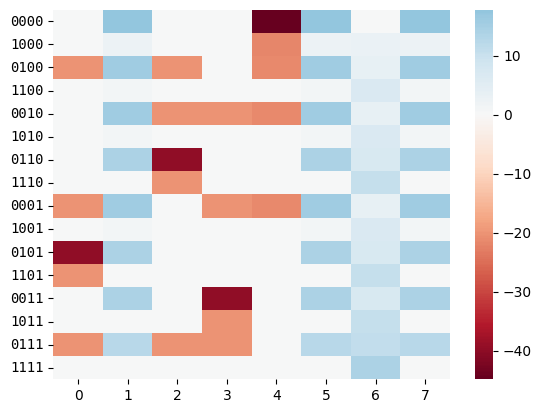

In [21]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

()

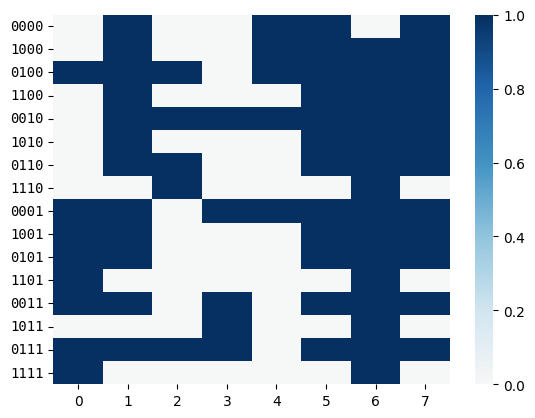

In [22]:
ax = sns.heatmap(x2 >= 0, cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

In [235]:
l2_synth[neuron_mask]

tensor([ 5.6304, -1.7026, -8.3918, -3.9007, -4.8538, -7.6129, -7.7657,  1.5806,
         5.3819,  7.7784,  8.7952])

In [23]:
for x in l1_for_task0[neuron_mask][:, 0] / 3.40333 * 16 * 6:
    print(f"{x:.6f}", end=" ")

-0.000004 80.107346 -0.000005 -0.000002 113.371536 79.976242 -1.604484 80.198395 

<Axes: >

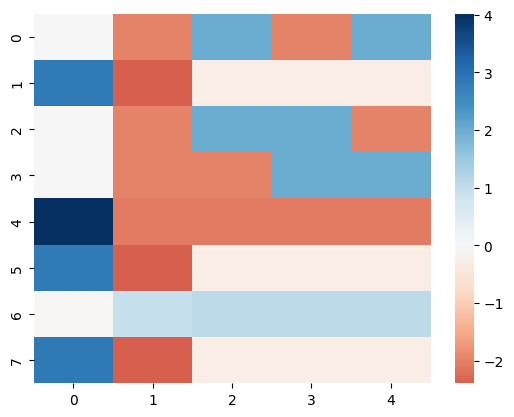

In [24]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

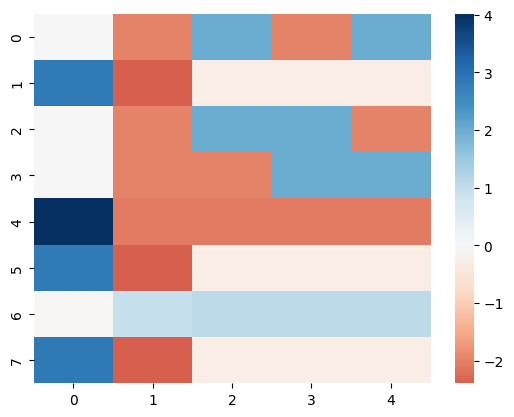

In [25]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

()

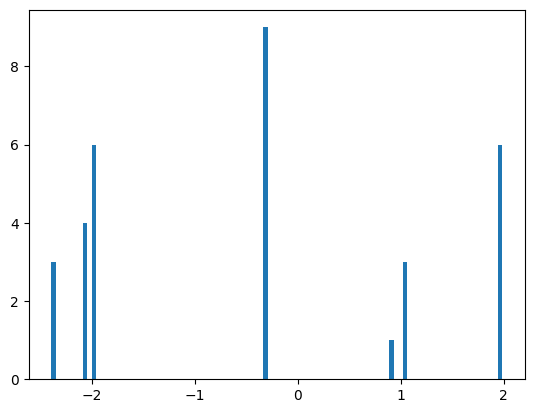

In [26]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)
()

In [30]:
(x3 * l2_synth[neuron_mask])

tensor([[ -0.0000,  17.7303,  -0.0000,  -0.0000, -44.8650,  17.6646,   0.0000,
          17.7757],
        [ -0.0000,   2.8015,  -0.0000,  -0.0000, -21.6966,   2.7926,   3.0076,
           2.8075],
        [-19.9370,  15.8910, -19.9364,  -0.0000, -21.5745,  15.8332,   3.5161,
          15.9309],
        [ -0.0000,   0.9622,  -0.0000,  -0.0000,  -0.0000,   0.9613,   6.7223,
           0.9627],
        [ -0.0000,  15.8909, -19.9364, -19.9366, -21.5745,  15.8332,   3.5162,
          15.9308],
        [ -0.0000,   0.9622,  -0.0000,  -0.0000,  -0.0000,   0.9612,   6.7225,
           0.9626],
        [ -0.0000,  14.0516, -39.8728,  -0.0000,  -0.0000,  14.0018,   7.2310,
          14.0860],
        [ -0.0000,   0.0000, -19.9364,  -0.0000,  -0.0000,   0.0000,  10.4372,
           0.0000],
        [-19.9370,  15.8909,  -0.0000, -19.9366, -21.5746,  15.8332,   3.5165,
          15.9308],
        [ -0.0000,   0.9621,  -0.0000,  -0.0000,  -0.0000,   0.9612,   6.7228,
           0.9626],
        [-

()

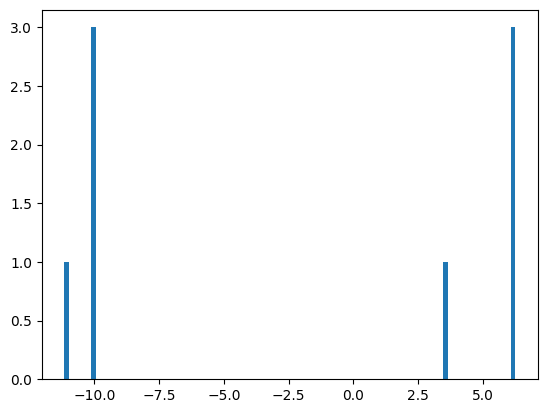

In [31]:
# plt.hist((l2_synth[neuron_mask].reshape(-1) - 1.6)/4.1, bins=100)
plt.hist((l2_synth[neuron_mask].reshape(-1)), bins=100)
()

In [32]:
(x3 * l2_synth[neuron_mask]).sum(-1)

tensor([  8.3056, -10.2873, -10.2768,   9.6085, -10.2763,   9.6085,   9.4976,
         -9.4992, -10.2769,   9.6087,   9.4965,  -9.4995,   9.4973,  -9.4990,
        -12.2402,  14.1524])

In [33]:
logits = (x3 * l2_synth[neuron_mask]).sum(-1)
target = bits.sum(-1) % 2
F.binary_cross_entropy_with_logits(
    -logits, target.float()
)  # .float() as binary_cross_entropy_with_logits supports soft targets

tensor(6.5071e-05)

<Axes: >

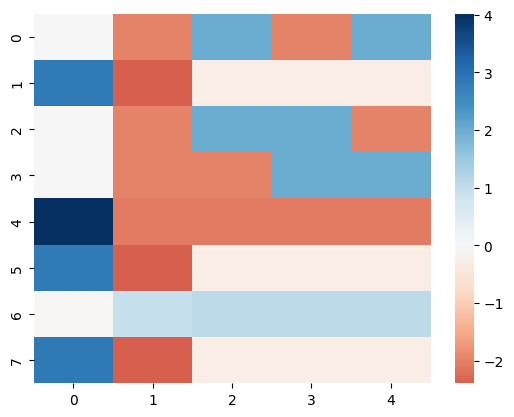

In [34]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

In [35]:
l1_for_task0[neuron_mask][:, 1:].shape

torch.Size([8, 4])

(array([3., 0., 0., 0., 0., 0., 0., 4., 0., 6., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 9., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 3., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6.]),
 array([-2.39409256, -2.35031962, -2.30654669, -2.26277375, -2.21900105,
        -2.17522812, -2.13145518, -2.08768225, -2.04390931, -2.00013638,
        -1.95636356, -1.91259062, -1.86881781, -1.82504487, -1.78127193,
        -1.737499  , -1.69372606, -1.64995325, -1.60618031, -1.56240749,
        -1.51863456, -1.47486162, -1.43108869, -1.38731575, -1.34354293,
        -1.29977   , -1.25599706, -1.21222425, -1.16845131, -1.12467837,
        -1.08090544, -1.03713262, -0.99335968, -0.94958675, -0.90581393,
        -0.862041  , -0.81826806, -0.77

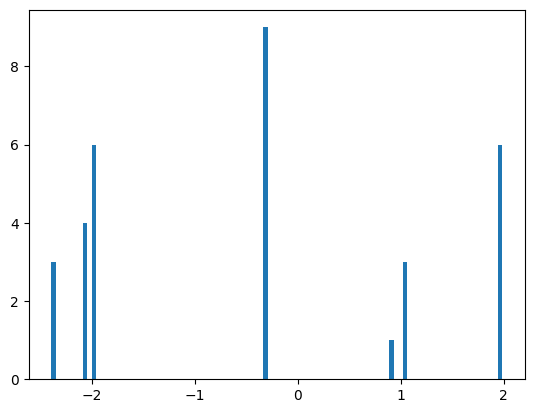

In [36]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)

In [100]:
l1_for_task0[neuron_mask][10]

tensor([ 2.4766, -2.4822, -2.4814,  2.4819, -2.4830])

tensor([ 2.8610e-06,  9.5367e-07,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         9.5367e-07,  0.0000e+00,  9.5367e-07,  0.0000e+00,  9.5367e-07,
        -9.5367e-07,  0.0000e+00,  3.8147e-06,  0.0000e+00,  9.5367e-07,
        -9.5367e-07])

In [65]:
l1_for_task0[neuron_mask].shape

torch.Size([11, 5])

In [56]:
# plt.plot(l2_synth[neuron_mask].sort().values.abs())

14

In [22]:
torch.tensor(2, dtype=torch.float).norm(2)

tensor(2.)

<Axes: >

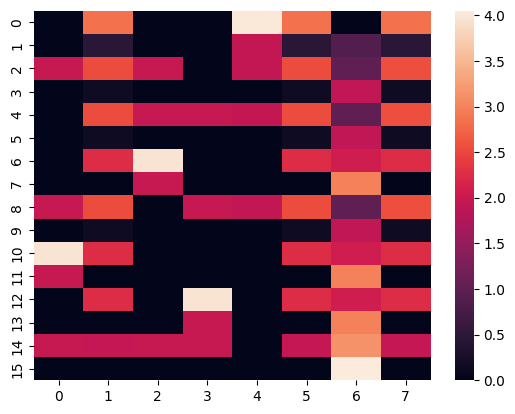

In [37]:
sns.heatmap(F.relu(input=x2))

<Axes: >

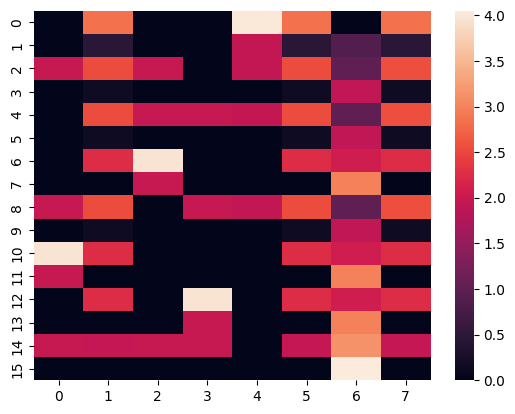

In [38]:
sns.heatmap(F.relu(input=x2))

In [22]:
a = F.relu(input=x2) @ ((l2_synth > 0) * 2 - 1).float()
a

tensor([ 0.9016, -2.0912,  0.0547,  0.9204, -1.4292, -0.0093,  1.6414, -0.4008,
        -0.8184, -0.1702,  1.6079, -0.2051,  3.7027, -1.3897, -0.2228,  2.0841])

In [23]:
(bits.sum(-1) % 2 == 0) == (a > 0)

tensor([ True,  True, False,  True,  True, False,  True,  True,  True, False,
         True,  True,  True,  True,  True,  True])

In [24]:
bits

tensor([[0, 0, 0, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [1, 1, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [1, 1, 1, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 1],
        [0, 1, 0, 1],
        [1, 1, 0, 1],
        [0, 0, 1, 1],
        [1, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 1, 1, 1]])

<Axes: >

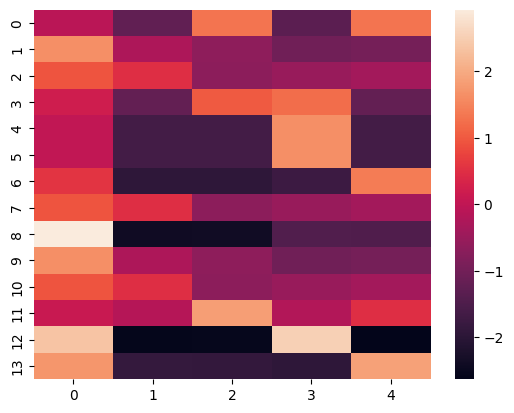

In [25]:
sns.heatmap(l1_for_task0)

<Axes: >

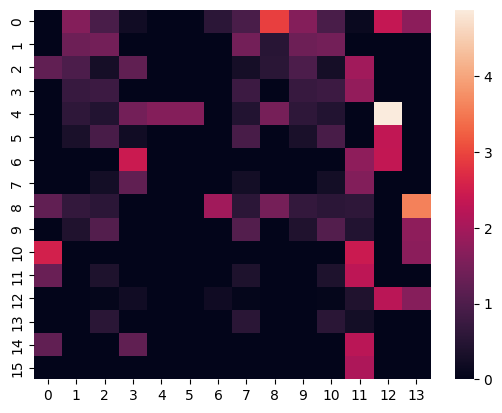

In [26]:
sns.heatmap(F.relu(input=x2))

<Axes: >

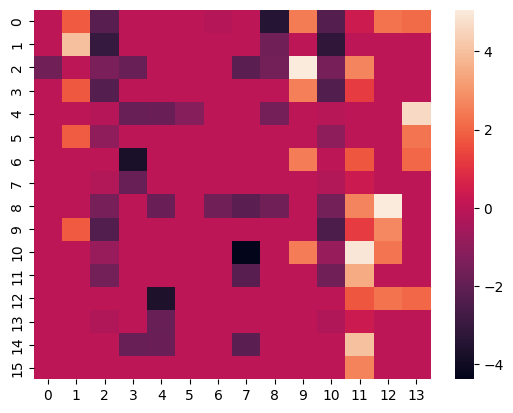

In [ ]:
# sns.heatmap((F.relu(input=x2) * l2_synth))
sns.heatmap((F.relu(input=x2) * ((l2_synth > 0) * 2 - 1)))

In [123]:
x4

tensor([ 17.6185, -11.8157, -15.4918,  15.6542, -13.2808,  19.9999,  11.8941,
        -15.3787, -15.1771,  15.5628,  18.5022, -15.0493,  11.9677, -15.2677,
        -24.1513,  13.5810])

In [ ]:
model.l1.weight[torch,]

IndexError: index 33 is out of bounds for dimension 0 with size 31

In [47]:
l2_synth @ model.l1.weight.data[:, 0]

tensor(18.6701)

In [48]:
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = model.l2(x3)
x4

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

In [15]:
batch_sz = 1
task_ids = torch.tensor([0])
bits = torch.tensor([0, 0, 0, 0])
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[0, dataset.selected_bits_by_task[0]] = bits

In [49]:
task_id = 0
batch_sz = 2**config.n_xored_bits
task_ids = torch.tensor([task_id]).repeat(batch_sz)
# bits = torch.tensor([0,0,0,0])
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[task_id]] = bits

In [50]:
# l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = x3 @ l2_synth

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

x4

tensor([ 17.6185, -15.1771, -15.4918,  18.5022, -13.2808,  11.9677,  11.8941,
        -24.1513, -11.8157,  15.5628,  15.6542, -15.0493,  19.9999, -15.2677,
        -15.3787,  13.5810])

In [57]:
l2_synth @ F.relu(model.l1.weight.data[:, 0])

tensor(17.6185)

<Axes: >

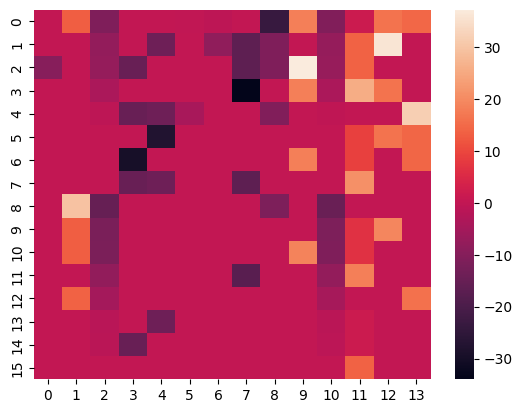

In [65]:
sns.heatmap((x3 * l2_synth))

In [139]:
dataset.selected_bits_by_task[0]

tensor([ 7, 17, 21, 16])

In [140]:
model.l1.weight.data[[17]].shape

torch.Size([1, 40])

<Axes: >

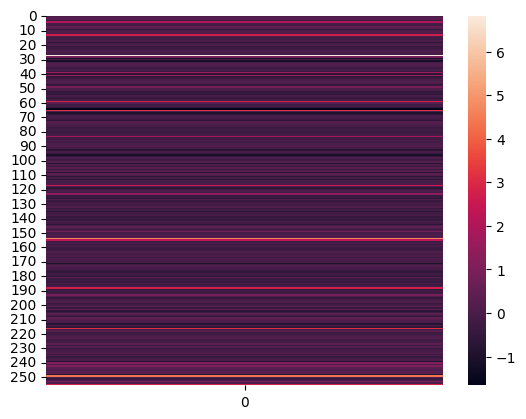

In [141]:
sns.heatmap(model.l1.weight.data[:, [0]])


<Axes: >

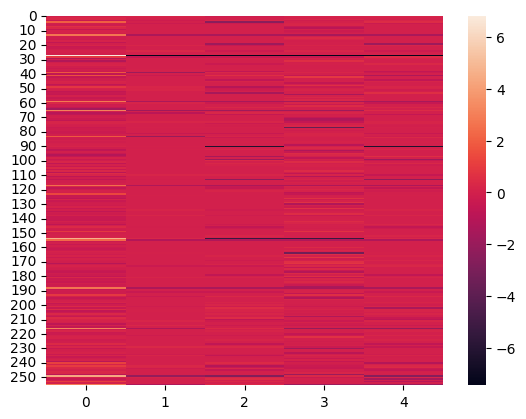

In [ ]:
sns.heatmap(
    model.l1.weight.data[:, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0] + 10])]
)

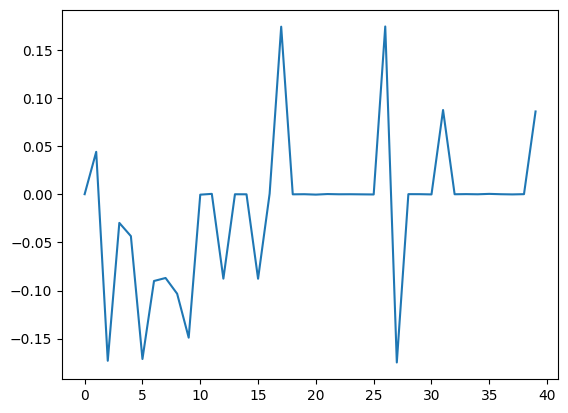

In [143]:
plt.plot(model.l1.weight.data[0])

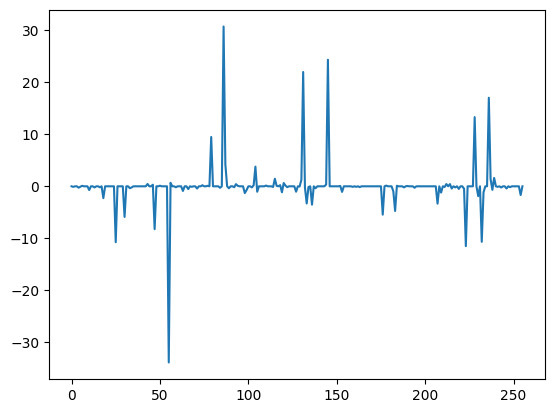

In [146]:
plt.plot((x3 * l2_synth)[0])
# plt.plot((x3 * l2_synth)[1])
# plt.plot((x3 * l2_synth)[2])
# plt.plot((x3 * l2_synth)[3])
# plt.plot((x3 * l2_synth)[14])
# plt.plot((x3 * l2_synth)[15])

In [119]:
(x3 * l2_synth)[15].sum()

tensor(9.2621)

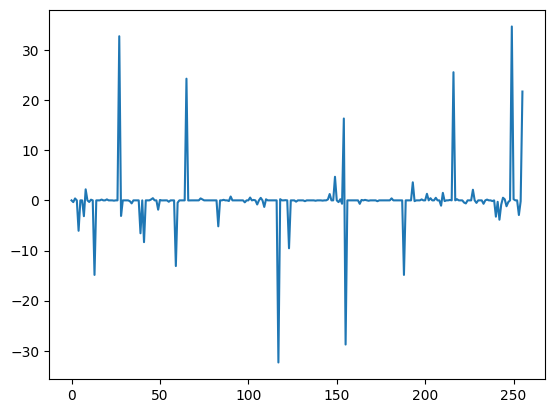

In [24]:
plt.plot((x3 * l2_synth)[0])

In [15]:
l2_synth.shape

torch.Size([256])

In [16]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [17]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [ ]:
einops.einsum(model.l2.weight.data, x3, 'two '

torch.Size([2, 256])

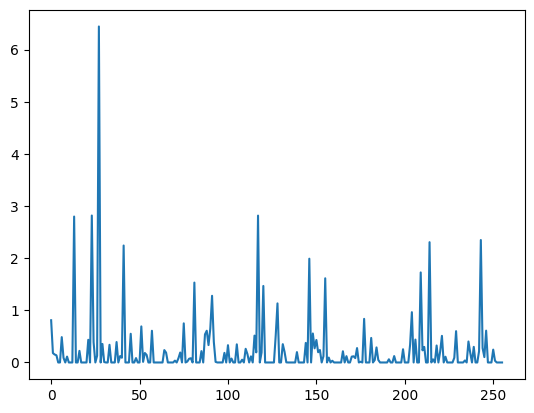

In [21]:
plt.plot(x3[0])

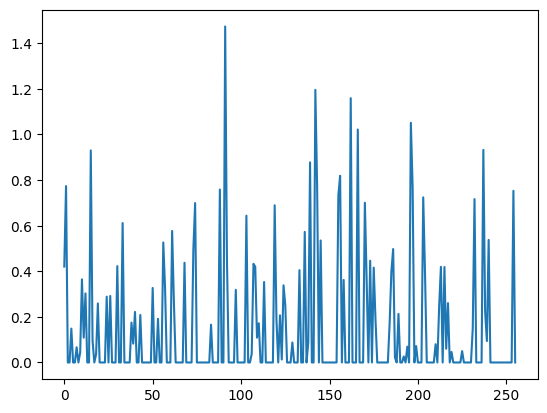

In [121]:
plt.plot(x3[0].detach())

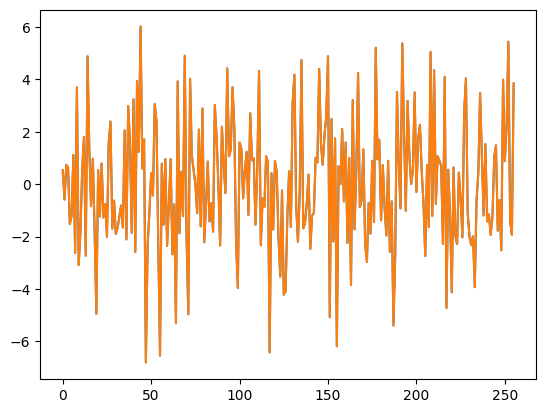

In [20]:
plt.plot(model.l2.weight.data[0])
plt.plot(-model.l2.weight.data[1])

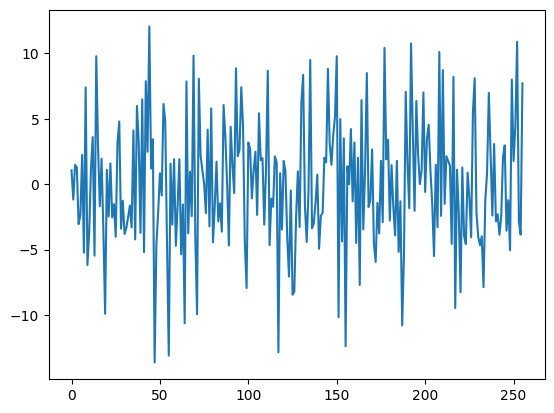

In [19]:
plt.plot(model.l2.weight.data[0] - model.l2.weight.data[1])

In [61]:
torch.randint(2, (1, config.n_xored_bits))

tensor([[1, 1, 1, 0]])

In [22]:
# plt.plot((model.l2.weight.data[0] - model.l2.weight.data[1]))
# plt.plot(model.l1.bias.data)

<Axes: >

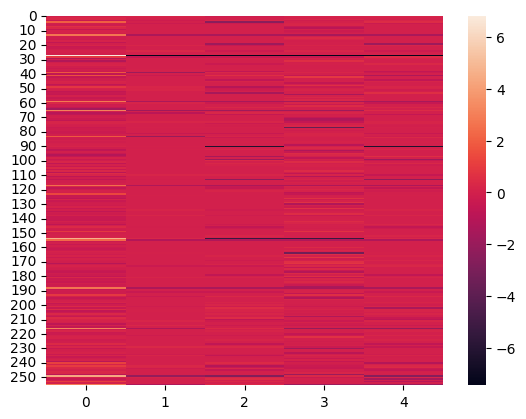

In [23]:
sns.heatmap(model.l1.weight.data[:, [0, 10 + 7, 10 + 17, 10 + 21, 10 + 16]])

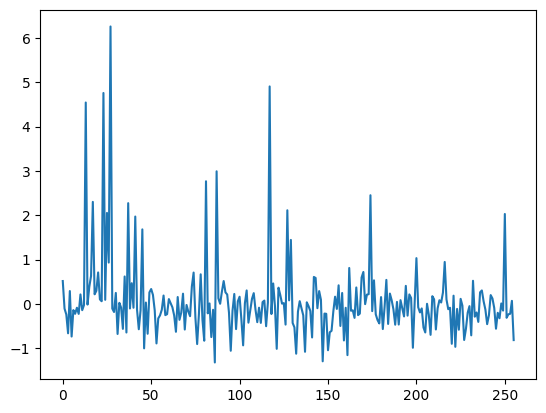

In [37]:
plt.plot(model.l1.weight.data[:, 0])

<Axes: >

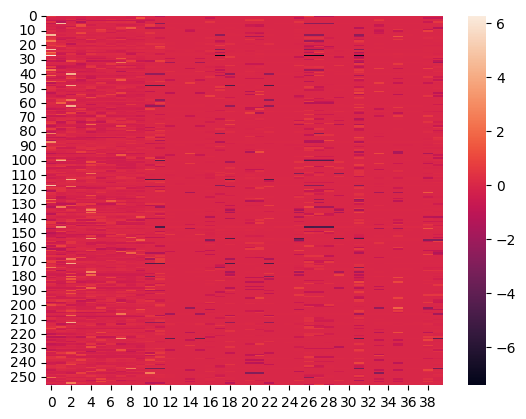

In [6]:
sns.heatmap(model.l1.weight.data)

In [7]:
(torch.arange(10, dtype=torch.float) + 1) ** -(0.4)

tensor([1.0000, 0.7579, 0.6444, 0.5743, 0.5253, 0.4884, 0.4592, 0.4353, 0.4152,
        0.3981])

In [ ]:
(torch.arange(10, dtype=torch.float) + 1) ** -(1 + 0.4)

tensor([1.0000, 0.3789, 0.2148, 0.1436, 0.1051, 0.0814, 0.0656, 0.0544, 0.0461,
        0.0398])